В Нью-Йорке более 260 уникальных зон (PULocationID). Прогнозировать спрос для каждой зоны отдельно — значит столкнуться с сильным шумом (разреженными матрицами), так как в непопулярных зонах поездок может быть ноль. Обучение модели на таких данных будет нестабильным.Решение: сгруппировать соседние зоны в макро-регионы (кластеры). Мы будем использовать пространственную кластеризацию с помощью алгоритма K-Means на основе координат зон (PU_lon и PU_lat). Алгоритм минимизирует внутрикластерную дисперсию, находя оптимальные центры макро-регионов:$$\arg\min_S \sum_{i=1}^k \sum_{x \in S_i} \|x - \mu_i\|^2$$

Шаг 1: Загрузка данных и подготовка временных признаков
Сначала загрузим датасет с погодой и извлечем из времени посадки tpep_pickup_datetime ключевые признаки для будущего прогнозирования спроса: час дня и день недели.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet('my_clean_3_with_weather.parquet')

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

Шаг 2: Формирование профиля зон
Чтобы кластеризовать районы, нам нужно получить уникальные координаты для каждого PULocationID. Поскольку в исходных данных могут быть микроскопические погрешности в координатах внутри одной зоны, мы возьмем медианное значение долготы и широты для каждого ID.

In [7]:
zone_profiles = df.groupby('PULocationID').agg(
    PU_lon=('PU_lon', 'median'),
    PU_lat=('PU_lat', 'median')
).reset_index()

zone_profiles = zone_profiles.dropna(subset=['PU_lon', 'PU_lat'])

Шаг 3: Кластеризация K-Means
Перед применением центроидного алгоритма данные необходимо стандартизировать, чтобы широта и долгота вносили равноценный вклад в расчет евклидова расстояния. Мы разобьем Нью-Йорк на 20 макро-регионов (число n_clusters можно будет затюнить позже с помощью метода локтя или silhouette score).

In [8]:
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(zone_profiles[['PU_lon', 'PU_lat']])

n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
zone_profiles['cluster_id'] = kmeans.fit_predict(coords_scaled)

Шаг 4: Объединение кластеров с основным датасетом
Теперь, когда каждая зона отнесена к определенному макро-региону (cluster_id), мы присоединяем эту информацию обратно к основному датасету. В будущем именно cluster_id будет выступать таргетом (или разрезом) для ранжирования зон в рекомендательной системе водителя.

In [9]:
df = df.merge(zone_profiles[['PULocationID', 'cluster_id']], on='PULocationID', how='left')

df = df.dropna(subset=['cluster_id'])
df['cluster_id'] = df['cluster_id'].astype(int)

Шаг 5: Визуализация полученных макро-регионов
Построим диаграмму рассеяния, чтобы визуально оценить, как K-Means разделил город на зоны. Каждому кластеру будет присвоен свой цвет.

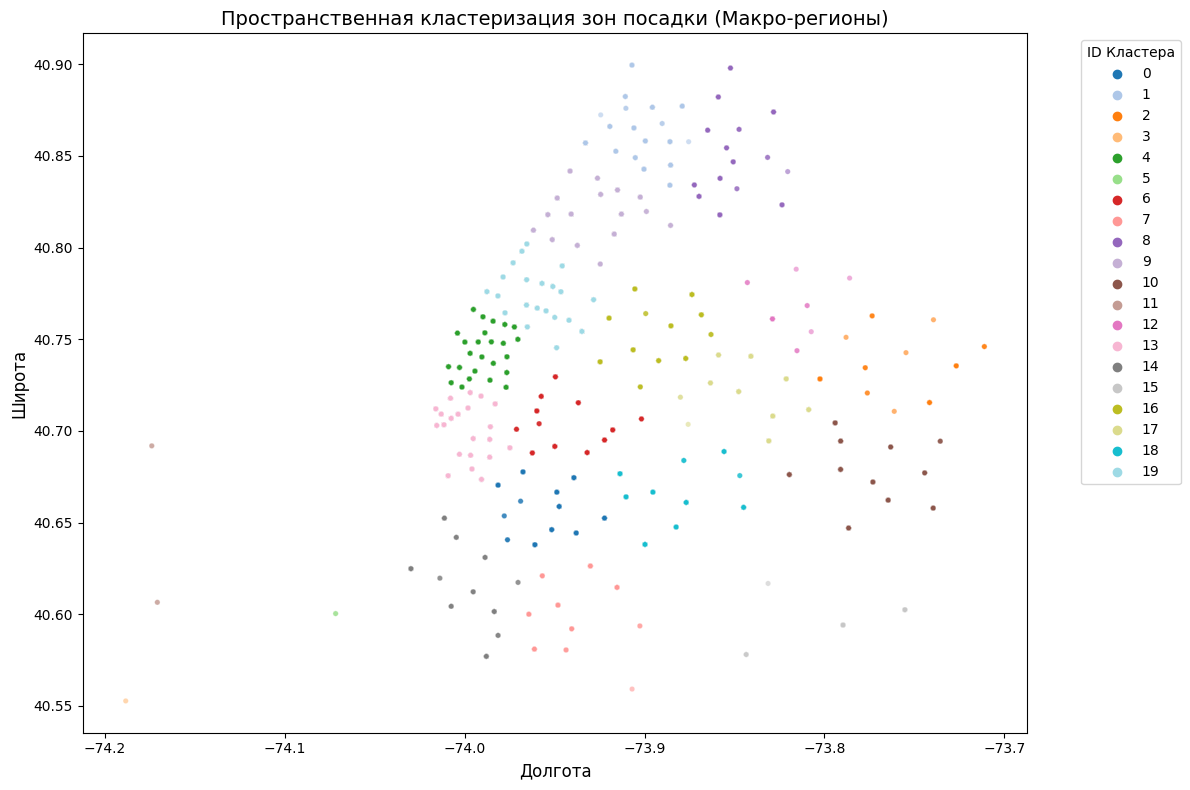

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df.sample(n=min(100000, len(df)), random_state=42), 
    x='PU_lon', 
    y='PU_lat', 
    hue='cluster_id', 
    palette='tab20', 
    s=15, 
    alpha=0.6,
    legend='full'
)

plt.title('Пространственная кластеризация зон посадки (Макро-регионы)', fontsize=14)
plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='ID Кластера')
plt.tight_layout()
plt.show()

Подготовка таргета (целевой переменной)

Сейчас в нашем датасете каждая строчка — это одна поездка. Но мы хотим предсказывать спрос (количество поездок) в конкретной зоне в конкретный час. Это значит, что нам нужно трансформировать датасет: сгруппировать данные по дате, часу и зоне посадки, а затем посчитать количество строк. Это количество и станет нашим таргетом ($y$).

В качестве простой базовой модели (baseline) возьмем Случайный лес (Random Forest). В отличие от линейной регрессии, деревья отлично улавливают нелинейные зависимости (например, тот факт, что в 18:00 пятницы спрос ведет себя иначе, чем в 18:00 воскресенья), и при этом лес работает прямо «из коробки». А уже на следующем этапе перейдем к бустингам, которые используют градиентный спуск для оптимизации ошибки.

Шаг 6: Агрегация данных (Переход к временным рядам)
Чтобы прогнозировать спрос, нам нужно посчитать количество поездок для каждой комбинации «Зона посадки + Дата + Час».

In [11]:
# 1. Считаем целевую переменную (спрос)
demand_df = df.groupby(['pickup_date', 'pickup_hour', 'PULocationID']).size().reset_index(name='demand')

# 2. Подтягиваем пространственные признаки (cluster_id)
zone_features = df[['PULocationID', 'cluster_id']].drop_duplicates()
demand_df = demand_df.merge(zone_features, on='PULocationID', how='left')

# 3. Подтягиваем временные признаки (погода, день недели)
# Так как они зависят только от времени, берем уникальные связки дата-час
time_features = df[['pickup_date', 'pickup_hour', 'pickup_dayofweek', 'temperature', 'precipitation', 'weather_code']].drop_duplicates(subset=['pickup_date', 'pickup_hour'])
demand_df = demand_df.merge(time_features, on=['pickup_date', 'pickup_hour'], how='left')

# Удаляем возможные пропуски после джоинов
demand_df = demand_df.dropna()

Шаг 7: Разделение на обучающую и тестовую выборки
В задачах прогнозирования времени строго запрещено использовать случайное перемешивание (train_test_split), иначе модель «заглянет в будущее» (произойдет data leakage), и метрики будут нереалистично хорошими. Мы отсортируем данные по времени и отрежем последние несколько дней для тестирования.

In [12]:
# Сортируем данные хронологически
demand_df = demand_df.sort_values(by=['pickup_date', 'pickup_hour'])

# Берем последние 7 дней месяца в качестве теста
split_date = demand_df['pickup_date'].max() - pd.Timedelta(days=7)

train = demand_df[demand_df['pickup_date'] < split_date]
test = demand_df[demand_df['pickup_date'] >= split_date]

# Определяем фичи (X) и таргет (y)
features = ['PULocationID', 'cluster_id', 'pickup_hour', 'pickup_dayofweek', 'temperature', 'precipitation', 'weather_code']
target = 'demand'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Размер трейна: {X_train.shape[0]} строк")
print(f"Размер теста: {X_test.shape[0]} строк")

Размер трейна: 940491 строк
Размер теста: 10170 строк


Шаг 8: Обучение базовой модели
Используем RandomForestRegressor. Мы ограничиваем количество деревьев (n_estimators=50) и глубину, чтобы обучение прошло быстро на этапе прототипирования. Оценивать качество будем по MAE (на сколько поездок мы в среднем ошибаемся).

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Инициализация и обучение модели
model_rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Предсказание на отложенной выборке
preds = model_rf.predict(X_test)

# Оценка качества
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"MAE (Средняя ошибка): {mae:.2f} поездок в час для зоны")
print(f"RMSE (Квадратичная ошибка): {rmse:.2f} поездок в час для зоны")

MAE (Средняя ошибка): 3.27 поездок в час для зоны
RMSE (Квадратичная ошибка): 5.53 поездок в час для зоны


Шаг 9: Ранжирование зон (Рекомендации водителю)
Главная бизнес-задача выполнена: теперь мы можем написать функцию, которая принимает на вход текущие условия среды (время и погоду), прогоняет через модель все доступные зоны Нью-Йорка и выдает топ-5 мест, куда водителю стоит поехать прямо сейчас, чтобы найти клиента.

In [14]:
def get_driver_recommendations(model, hour, dayofweek, temp, precip, weather_code, unique_zones, zone_clusters):
    # Создаем датафрейм со всеми зонами
    df_pred = pd.DataFrame({'PULocationID': unique_zones})
    df_pred = df_pred.merge(zone_clusters, on='PULocationID', how='left')
    
    # Заполняем текущими условиями
    df_pred['pickup_hour'] = hour
    df_pred['pickup_dayofweek'] = dayofweek
    df_pred['temperature'] = temp
    df_pred['precipitation'] = precip
    df_pred['weather_code'] = weather_code
    
    # Порядок колонок строго как при обучении
    X_pred = df_pred[['PULocationID', 'cluster_id', 'pickup_hour', 'pickup_dayofweek', 'temperature', 'precipitation', 'weather_code']]
    
    # Прогнозируем спрос
    df_pred['expected_demand'] = model.predict(X_pred)
    
    # Ранжируем зоны по убыванию ожидаемого спроса
    top_zones = df_pred.sort_values(by='expected_demand', ascending=False).head(5)
    
    return top_zones[['PULocationID', 'cluster_id', 'expected_demand']]

# Симуляция: Пятница (dayofweek=4), 18:00, температура 15 градусов, без осадков
unique_zones_list = demand_df['PULocationID'].unique()
clusters_mapping = demand_df[['PULocationID', 'cluster_id']].drop_duplicates()

recommendations = get_driver_recommendations(
    model_rf, 
    hour=18, dayofweek=4, temp=15.0, precip=0.0, weather_code=1.0, 
    unique_zones=unique_zones_list, 
    zone_clusters=clusters_mapping
)

print("Рекомендуемые зоны для водителя:")
display(recommendations)

Рекомендуемые зоны для водителя:


,PULocationID,cluster_id,expected_demand
50,236,19,39.727377
51,237,19,39.461655
33,161,4,38.678468
21,132,10,31.924399
34,162,4,30.836274


Что будем делать дальше?
Переходим к градиентному бустингу. В отличие от случайного леса, который строит деревья независимо, бустинг строит их последовательно: каждое новое дерево пытается исправить ошибки предыдущих, используя градиентный спуск.

Мы будем использовать CatBoost. Это мощная библиотека от Яндекса, которая идеально подходит для твоей задачи по одной главной причине: у тебя много категориальных признаков (PULocationID, cluster_id, pickup_dayofweek, weather_code). Твой случайный лес воспринимал ID зон как обычные числа (считая, что зона 200 больше, чем зона 100), что математически неверно. CatBoost умеет работать с категориями нативно, под капотом превращая их в умные статистики, что сразу даст сильный прирост в качестве прогноза.

### Шаг 10: Улучшение модели (Градиентный бустинг с CatBoost)

Случайный лес — отличный бейзлайн, но для выжимания максимума из табличных данных лучше использовать градиентный бустинг. Алгоритм строит деревья последовательно, минимизируя функцию потерь (в нашем случае среднеквадратичную ошибку) на каждом шаге:

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

где $\nu$ — скорость обучения (learning rate), а $h_m(x)$ — новое дерево, аппроксимирующее антиградиент.

Мы используем **CatBoost**, так как наши признаки `PULocationID`, `cluster_id`, `pickup_dayofweek` и `weather_code` не являются непрерывными числами — это категории. CatBoost умеет обрабатывать их нативно, извлекая сложные зависимости без ручного кодирования.

In [15]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 246.6 kB/s eta 0:06:45
   ---------------------------------------- 0.5/100.2 MB 246.6 kB/s eta 0:06:45
   ---------------------------------------- 0.5/100.2 MB 246.6 kB/s eta 0:06:45
   ---------------------------------------- 0.5/100.2 MB 246.6 kB/s eta 0:06:45
   --------------------------------------

In [16]:
from catboost import CatBoostRegressor

# Явно указываем модели, какие признаки являются категориальными
cat_features = ['PULocationID', 'cluster_id', 'pickup_dayofweek', 'weather_code']

# Приводим категориальные признаки к типу int (CatBoost требует int или string)
for col in cat_features:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Инициализация модели.
# iterations=500 - максимальное количество деревьев
# learning_rate=0.1 - шаг градиентного спуска (темп обучения)
model_cb = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function='RMSE',
    eval_metric='MAE',
    random_seed=42,
    verbose=100 # Выводить логи каждые 100 итераций
)

# Обучаем модель. Передаем валидационный сет (X_test), чтобы контролировать переобучение
model_cb.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50 # Остановим обучение, если ошибка на тесте не падает в течение 50 итераций
)

0:	learn: 6.2558112	test: 5.3346985	best: 5.3346985 (0)	total: 519ms	remaining: 4m 19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.214266891
bestIteration = 31

Shrink model to first 32 iterations.


CatBoostRegressor(depth=8, eval_metric='MAE', iterations=500, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

### Шаг 11: Оценка качества градиентного бустинга

Сравним метрики новой модели с результатами случайного леса на тестовой выборке.

In [17]:
preds_cb = model_cb.predict(X_test)

# Зануляем отрицательные прогнозы, так как физический спрос (количество поездок) не может быть меньше нуля
preds_cb = np.maximum(0, preds_cb)

# Расчет метрик для CatBoost
mae_cb = mean_absolute_error(y_test, preds_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, preds_cb))

print("--- Случайный лес (Baseline) ---")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

print("\n--- CatBoost (Gradient Boosting) ---")
print(f"MAE: {mae_cb:.2f}, RMSE: {rmse_cb:.2f}")

# Считаем относительный прирост качества
improvement = ((mae - mae_cb) / mae) * 100
print(f"\nУлучшение метрики MAE составило: {improvement:.1f}%")

--- Случайный лес (Baseline) ---
MAE: 3.27, RMSE: 5.53

--- CatBoost (Gradient Boosting) ---
MAE: 3.21, RMSE: 4.80

Улучшение метрики MAE составило: 1.6%


В чем главный прикол этих цифр?
MAE улучшился всего на 1.6% (с 3.27 до 3.21). Кажется, что сдвиг крошечный.

RMSE упал аж на 13.2% (с 5.53 до 4.80). А вот это уже серьезная победа!

Что это значит на человеческом языке?
Метрика RMSE из-за возведения ошибок в квадрат очень чувствительна к крупным промахам. То, что RMSE заметно снизился, говорит о следующем: CatBoost не просто стал чуть точнее в среднем, он перестал совершать катастрофические ошибки.

Случайный лес мог в условную пятницу вечером в центре Манхэттена (где спрос зашкаливает) жестко недооценить ситуацию и предсказать мало поездок, ошибившись на 20–30 машин. CatBoost за счет последовательного исправления ошибок градиентным спуском эти "пики" выучил гораздо лучше. Для бизнеса такси это критично: лучше ошибаться по чуть-чуть везде, чем один раз отправить водителя в абсолютно пустую зону в час пик.

### Шаг 12: Анализ важности признаков (Feature Importance)

Посмотрим, на какие признаки модель опирается сильнее всего при прогнозировании спроса на такси. Это поможет интерпретировать результаты градиентного бустинка.

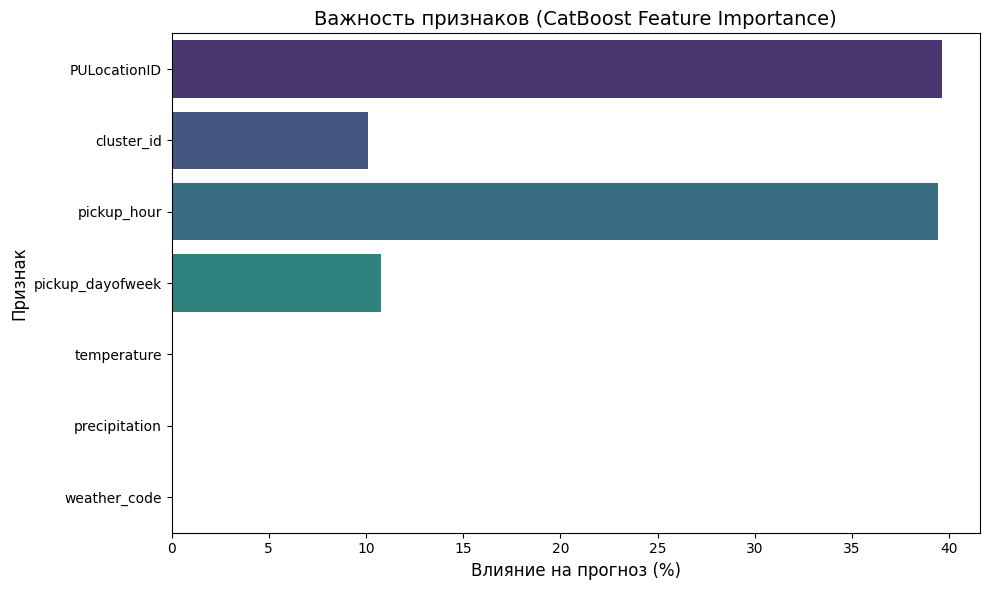

In [18]:
feature_importances = model_cb.get_feature_importance()

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=X_train.columns, palette='viridis')
plt.title('Важность признаков (CatBoost Feature Importance)', fontsize=14)
plt.xlabel('Влияние на прогноз (%)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

Видно, что час суток (pickup_hour) и ID зоны/кластера улетели далеко вперед, оставив погоду далеко позади.

Это абсолютно нормальная и логичная картина для транспортных задач:

Людям важнее, что сейчас 8:30 утра (время ехать на работу), чем то, что на улице капает слабый дождь.

Погода выступает скорее "модификатором" (в ливень спрос вырастет на 10–15%), но базовую структуру спроса все равно формируют время и география.